# Portugal Housing Price Prediction
## Advanced supervised learning and deployment


### Table of contents

1. Imports and setup
2. Problem definition
3. Data loading and first audit
4. Data cleaning
5. Train / test split
6. Exploratory data analysis
7. Statistical inference
8. Preprocessing strategy
9. Baseline models
10. Model comparison with cross-validation
11. Hyperparameter tuning
12. Ensemble methods
13. Final test evaluation
14. Error analysis and interpretation
15. Deployment
16. Dashboard
17. Conclusion, limitations, and recommendations

---
## 1. Imports and setup


In [1]:
# Standard library
import sys
from pathlib import Path
import warnings

# Suppress noisy sklearn UserWarnings during GridSearchCV
warnings.filterwarnings("ignore", category=UserWarning)

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# sklearn
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    VotingRegressor, StackingRegressor,
)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

# Project package
sys.path.insert(0, str(Path.cwd().parent))
from portugal_housing.config import *
from portugal_housing.dataset import *
from portugal_housing.features import *
from portugal_housing.plots import *
from portugal_housing.statistics import *
from portugal_housing.modeling.train import cv_compare
from portugal_housing.modeling.predict import evaluate_model, compare_final_metrics

# Apply project-wide plot style
apply_global_style()

# Paths
DATA_PATH   = Path.cwd().parent / "data" / "raw" / "portugal_listinigs.csv"
FIG_DIR     = Path.cwd().parent / "reports" / "figures"

---
## 2. Problem definition

| Field | Value |
|-------|-------|
| **Author** | Hussein Loubani |
| **Dataset** | Real Estate Listings in Portugal (Kaggle) |
| **Date** | 2026-04-19 |
| **Objective** | Predict asking price (€) for Portuguese real estate listings |
| **Model type** | Regression (supervised) |

**Business context.** Portugal Real Estate Brokers want a model that flags underpriced listings. When the predicted price is meaningfully above the asking price, a broker reaches out to the owner about a possible purchase. The model is meant to run as an automated API, called whenever a new listing appears on the platforms the firm scrapes.

**One thing to keep in mind.** The target here is the *asking* price on a listing, not the price the property eventually sells for. Predictions reflect how sellers price their listings in this dataset, not true market value. Sale-price prediction would need transaction data we do not have.


### Machine learning formulation

| | |
|---|---|
| **Problem type** | Regression |
| **Target** | `price` (asking price in Euros, continuous) |
| **Features** | 11 property attributes: area and living area, rooms, bathrooms, parking, construction year, elevator, district, city, type, energy certificate |
| **Primary metric** | RMSE: reported in euros, penalizes large misses heavily |
| **Secondary metrics** | MAE, R², MAPE |
| **Baseline** | Mean predictor (DummyRegressor) and linear regression |

### Why RMSE?

RMSE is the primary metric because it is denominated in euros, the same unit as the target, so a score reads directly as "typical error, in €". It also penalizes large errors more than small ones, which matches the business cost: badly mispricing an expensive property is worse than being slightly off on a cheap one. MAE sits alongside it as a more outlier-tolerant view of the typical error, R² reports the share of price variance explained, and MAPE gives a percentage error that is comparable across price bands.

---
## 3. Data loading and first audit


### 3.1 Load data

In [2]:
df = load_data(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 135,536 rows × 25 columns


### 3.2 Variable glossary

| Column | Type | Description |
|--------|------|-------------|
| Price | float | Asking price in Euros (target) |
| District | str | Administrative district (e.g., Lisboa, Porto) |
| City | str | City name |
| Town | str | Town / parish name |
| Type | str | Property type (Apartment, House, Land, etc.) |
| EnergyCertificate | str | Energy efficiency rating (A+ to F, NC) |
| TotalArea | float | Total area (m²) |
| Parking | float | Number of parking spaces |
| Elevator | bool | Whether building has an elevator |
| ConstructionYear | float | Year the property was built |
| TotalRooms | float | Total number of rooms |
| LivingArea | float | Livable space (m²) |
| NumberOfBathrooms | float | Number of bathrooms |

*Columns with >50% missing data (GrossArea, Floor, PublishDate, BuiltArea, ConservationStatus, LotSize, NumberOfBedrooms, NumberOfWC, EnergyEfficiencyLevel, Garage, ElectricCarsCharging, HasParking) are documented in the data dictionary but will be dropped during cleaning.*

### 3.3 Audit data

In [3]:
summary = audit_data(df)
summary

Shape          : 135,536 rows × 25 columns
Duplicated rows: 8,913

Missing values detected:
                       missing_count  missing_%
ConservationStatus            116244      85.77
BuiltArea                     108919      80.36
GrossArea                     107898      79.61
Floor                         107607      79.39
PublishDate                   106297      78.43
LotSize                        95953      70.80
NumberOfBedrooms               88495      65.29
NumberOfWC                     78280      57.76
EnergyEfficiencyLevel          68247      50.35
Garage                         68247      50.35
ElectricCarsCharging           68247      50.35
HasParking                     67321      49.67
TotalRooms                     62292      45.96
ConstructionYear               47515      35.06
LivingArea                     30584      22.57
TotalArea                       8383       6.19
NumberOfBathrooms               6836       5.04
Price                            300       0

,dtype,n_unique,missing,missing_%,min,max,mean,median
column,,,,,,,,
Price,float64,4754,300,0.2,1.0,1380000000.0,368137.45,210000.0
District,object,27,0,0.0,N/A,N/A,N/A,N/A
City,object,275,0,0.0,N/A,N/A,N/A,N/A
Town,object,2263,2,0.0,N/A,N/A,N/A,N/A
Type,object,21,16,0.0,N/A,N/A,N/A,N/A
EnergyCertificate,object,12,14,0.0,N/A,N/A,N/A,N/A
GrossArea,float64,2267,107898,79.6,-7.0,12750000.0,2789.73,164.0
TotalArea,float64,7305,8383,6.2,-7196067.0,61420071105.0,514077.99,159.0
Parking,float64,4,194,0.1,0.0,3.0,0.55,0.0


In [4]:
print("Categorical feature value counts:")
inspect_categoricals(df, ["Type", "EnergyCertificate", "District"])

Categorical feature value counts:
  Type                      -> {'Apartment': 47378, 'House': 36736, 'Land': 31843, 'Store': 5333, 'Farm': 3889}  (+16 more)
  EnergyCertificate         -> {'NC': 61387, 'C': 16364, 'D': 15576, 'E': 10898, 'A': 9910}  (+7 more)
  District                  -> {'Lisboa': 31351, 'Porto': 22681, 'Setúbal': 11579, 'Braga': 11445, 'Faro': 8943}  (+22 more)


In [5]:
print("Target variable statistics:")
target_stats(df, target="Price")

Target variable statistics:


,count,mean,median,std,min,max,skew,kurtosis
Price,135236,368137.45,210000.0,3804044.27,1.0,1.380000e+09,352.81,127935.61


### 3.4 Numeric outlier check

In [6]:
print("Numeric outlier check (raw columns):")
anomaly_screen(df, ["Price", "TotalArea", "LivingArea", "Parking", "ConstructionYear", "TotalRooms", "NumberOfBathrooms"])

Numeric outlier check (raw columns):


,Q1,Q3,IQR,lower_fence,upper_fence,n_flagged,pct_flagged,note
feature,,,,,,,,
Price,84000.0,395000.0,311000.0,-382500.0,861500.0,10589,7.8,potential anomalies
TotalArea,91.0,500.0,409.0,-522.5,1113.5,21553,17.0,potential anomalies
LivingArea,80.0,204.0,124.0,-106.0,390.0,11967,11.4,potential anomalies
Parking,0.0,1.0,1.0,-1.5,2.5,7282,5.4,potential anomalies
ConstructionYear,1973.0,2009.0,36.0,1919.0,2063.0,361,0.4,potential anomalies
TotalRooms,2.0,4.0,2.0,-1.0,7.0,2893,3.9,potential anomalies
NumberOfBathrooms,0.0,2.0,2.0,-3.0,5.0,2743,2.1,potential anomalies


### 3.5 Audit findings

A few things stand out from the first pass over the raw file.

- Missingness is severe. 12 columns are above 50% missing and get dropped during cleaning. Of the columns kept, the worst are `TotalRooms` (46.0%), `ConstructionYear` (35.1%), `LivingArea` (22.6%), and `NumberOfBathrooms` (5.0%).
- Mixed-type warnings on columns like `HasParking` and `Floor` are typical of a scraped feed where different sources used slightly different conventions.
- Duplicates exist and are removed in Section 4.
- The price column ranges from €1 to €1.38B. Both ends are listing artifacts rather than real properties, so we trim them.
- Price is heavily right-skewed (skew > 5), which is why we look at log-price during EDA and lean on tree-based models that handle skewed targets without a transform.


---
## 4. Data cleaning


In [7]:
raw_df = df.copy()
duplicate_summary(raw_df)

Original  : 135,536 rows × 25 columns
Unique    : 126,623 rows
Duplicates: 8,913 rows (6.6%)


### 4.1 Duplicate impact assessment

Before dropping the duplicate rows, the same check Sprint 1 used: are the duplicates a random slice of the data, or a biased subset whose removal would shift the distributions? Columns are renamed to snake_case first so the feature lists line up, then each numerical feature is compared between unique and duplicate rows with a Mann-Whitney U test, and each categorical feature with a chi-square test.

In [8]:
from portugal_housing.config import RENAME_COLS

dup_check = raw_df.rename(columns=RENAME_COLS)
print("Numerical feature impact (unique records vs extra duplicate rows):")
duplicate_impact_numerical(dup_check)

Numerical feature impact (unique records vs extra duplicate rows):


,mean (all),mean (dedup),mean Δ%,median (all),median (dedup),median Δ%,p (Mann-Whitney),sig (α=0.05)
feature,,,,,,,,
total_area,514077.99,549880.60,6.96,159.0,159.0,0.00,0.0000,Yes
parking,0.55,0.54,-1.82,0.0,0.0,0.00,0.0000,Yes
construction_year,1989.30,1988.80,-0.03,1994.0,1993.0,-0.05,0.0000,Yes
total_rooms,3.23,3.24,0.31,3.0,3.0,0.00,0.0001,Yes
living_area,1403.04,1441.44,2.74,118.0,118.0,0.00,0.3122,No
number_of_bathrooms,1.54,1.54,0.00,1.0,1.0,0.00,0.9816,No


In [9]:
print("Categorical feature impact (unique records vs extra duplicate rows):")
duplicate_impact_categorical(dup_check)

Categorical feature impact (unique records vs extra duplicate rows):


,chi2,p-value,max prop. shift,sig (α=0.05)
feature,,,,
district,2560.048,0.0,0.49,Yes
city,5871.399,0.0,0.17,Yes
type,355.328,0.0,0.21,Yes
energy_certificate,1746.915,0.0,0.69,Yes


The duplicate rows are about 6.6% of the data, far less than the 37% seen in Sprint 1. Where a test does flag a significant difference, the practical shift in means and proportions is small. Dropping the duplicates does not meaningfully move the feature distributions, so it is safe and is folded into the cleaning pipeline below.

### 4.2 Cleaning pipeline

The `clean_data()` function does six things, in order:

1. Drops the 12 columns with more than 50% missing values.
2. Renames everything to snake_case.
3. Removes rows where price is missing or non-positive.
4. Trims prices outside the 1st and 99.5th percentiles to cut listing-noise extremes.
5. Removes negative area values, which are physically impossible.
6. Drops duplicate rows.

It is on the aggressive side, but every step is targeted at scrape artifacts rather than real signal. The cuts on price and area are the only ones that touch genuine data points; the percentile thresholds are conservative enough that we keep the bulk of the high-end market.


In [10]:
df = clean_data(df)

Cleaned dataset : 114,692 rows × 13 columns
Rows removed    : 20,844
Median price    : €215,000
Mean price      : €338,353


In [11]:
print("Property type distribution after cleaning:")
print(df["type"].value_counts().to_string())

Property type distribution after cleaning:
type
Apartment              41054
House                  33503
Land                   24309
Store                   4094
Farm                    3430
Building                2190
Transfer of lease       1321
Warehouse               1176
Garage                   721
Other - Commercial       657
Office                   578
Other - Residential      459
Duplex                   352
Industrial               323
Investment               179
Hotel                    119
Storage                   94
Studio                    55
Estate                    38
Mansion                   21
Manor                      4


### 4.3 Property type assessment

The dataset has 21 property types. Apartment and House dominate, Land is third, and the rest (Store, Farm, Building, and so on) are smaller segments.

I keep all of them in the model. Filtering down to residential-only would cut the sample by roughly 40% and throw away signal that helps the model tell, say, a 200 m² land plot apart from a 200 m² apartment. Tree-based models cope fine with category mixing, and the `type` feature is exactly what lets them do that.


In [12]:
PROCESSED_PATH = Path.cwd().parent / "data" / "processed" / "portugal_housing_clean.csv"
df.to_csv(PROCESSED_PATH, index=False)
print(f"Saved cleaned data: {PROCESSED_PATH}")

Saved cleaned data: /Users/hussein-loubani/Turing College/Module 3/Sprint 2/data/processed/portugal_housing_clean.csv


---
## 5. Train / test split


In [13]:
train_df, test_df = split_data(df)

Train set : 91,753 rows  (median price: €215,000)
Test set  : 22,939 rows  (median price: €215,000)


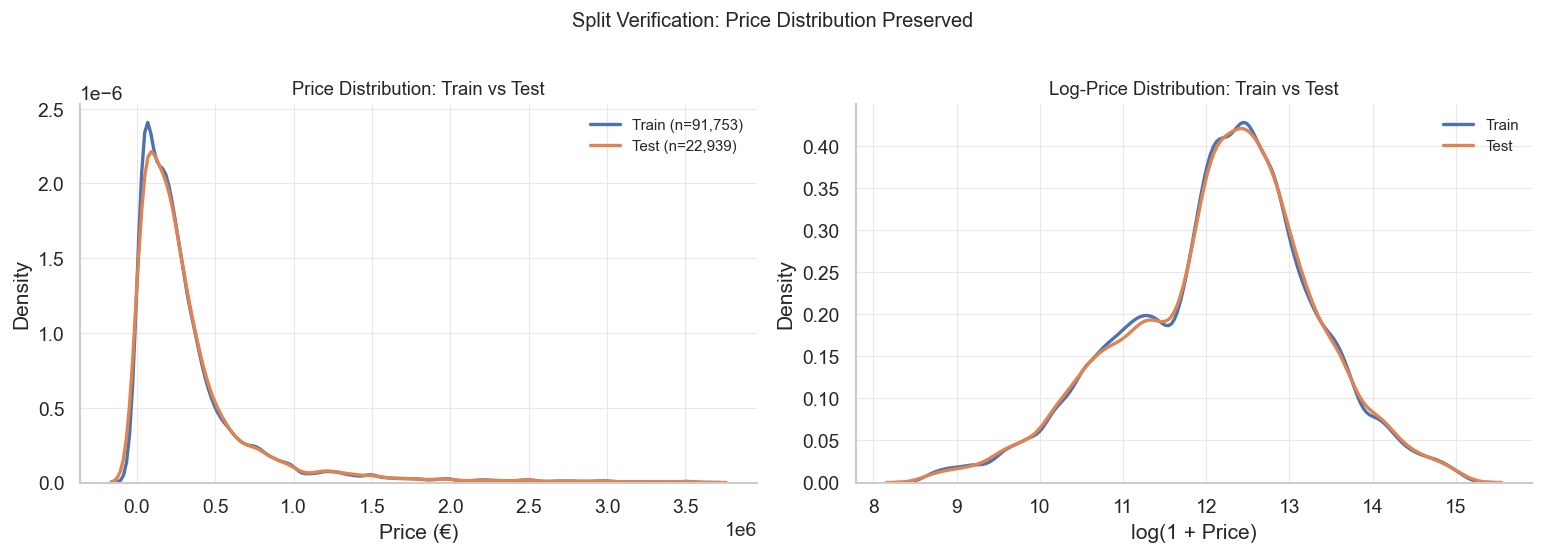

In [14]:
fig = plot_split_verification(train_df, test_df)
plt.show()
save_figure(fig, "split_verification", FIG_DIR / "train_test_split")

**Split design.**

I use a plain 80/20 random split. There is no need to stratify in regression here, and the KDE overlay later in this section confirms that the price distribution is preserved in both halves.

The test set is sealed at this point. Nothing in Sections 6 to 12 (EDA, statistical inference, preprocessing, modeling, tuning, ensembling) sees it. It is only opened in Section 13 for a one-shot final evaluation.


In [15]:
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

---
## 6. Exploratory data analysis


### 6.1 Target distribution


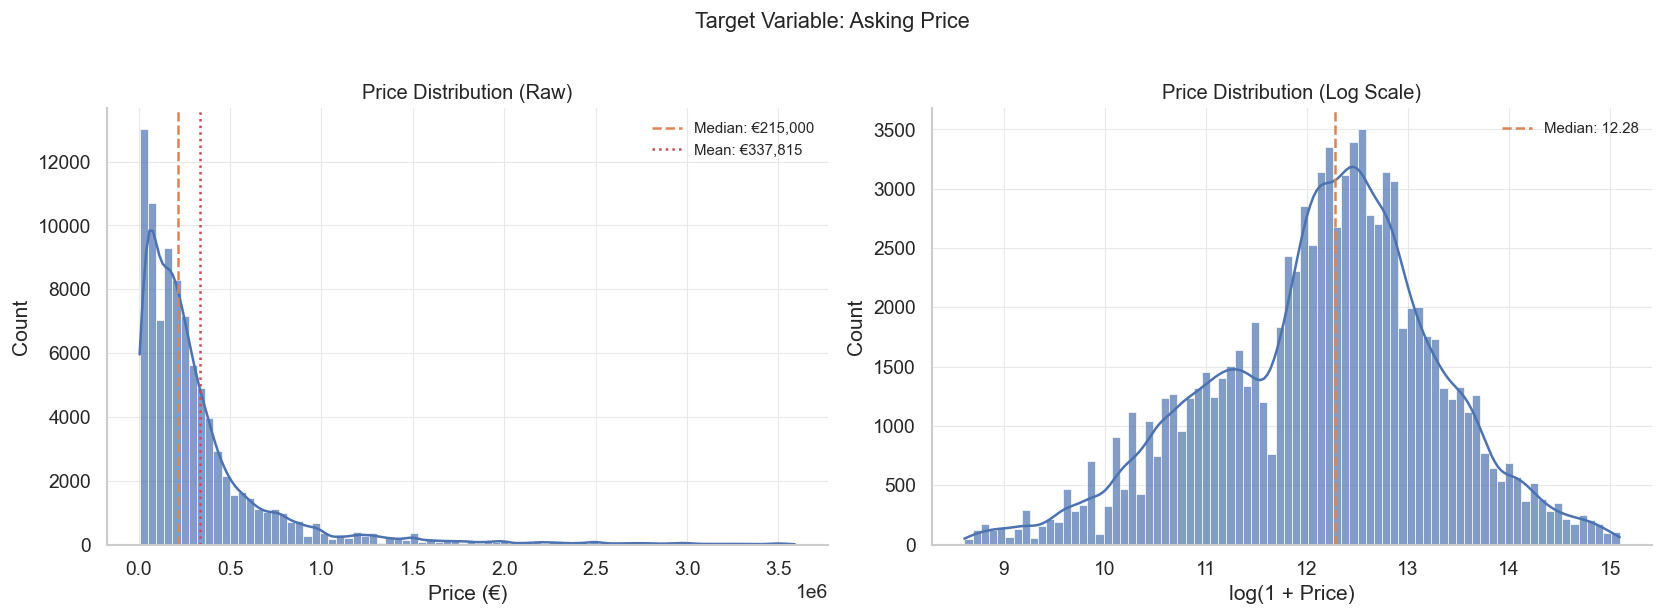

In [16]:
fig = plot_target_distribution(train_df)
plt.show()
save_figure(fig, "target_distribution", FIG_DIR / "eda")

- The raw price distribution has a long right tail. The median sits well below the mean, which is the usual signature of positive skew.
- `log(price)` is roughly normal, which means we have two reasonable options: model on the log scale, or stay on the original scale and rely on tree-based models that do not need a Gaussian target.


### 6.2 Feature distributions


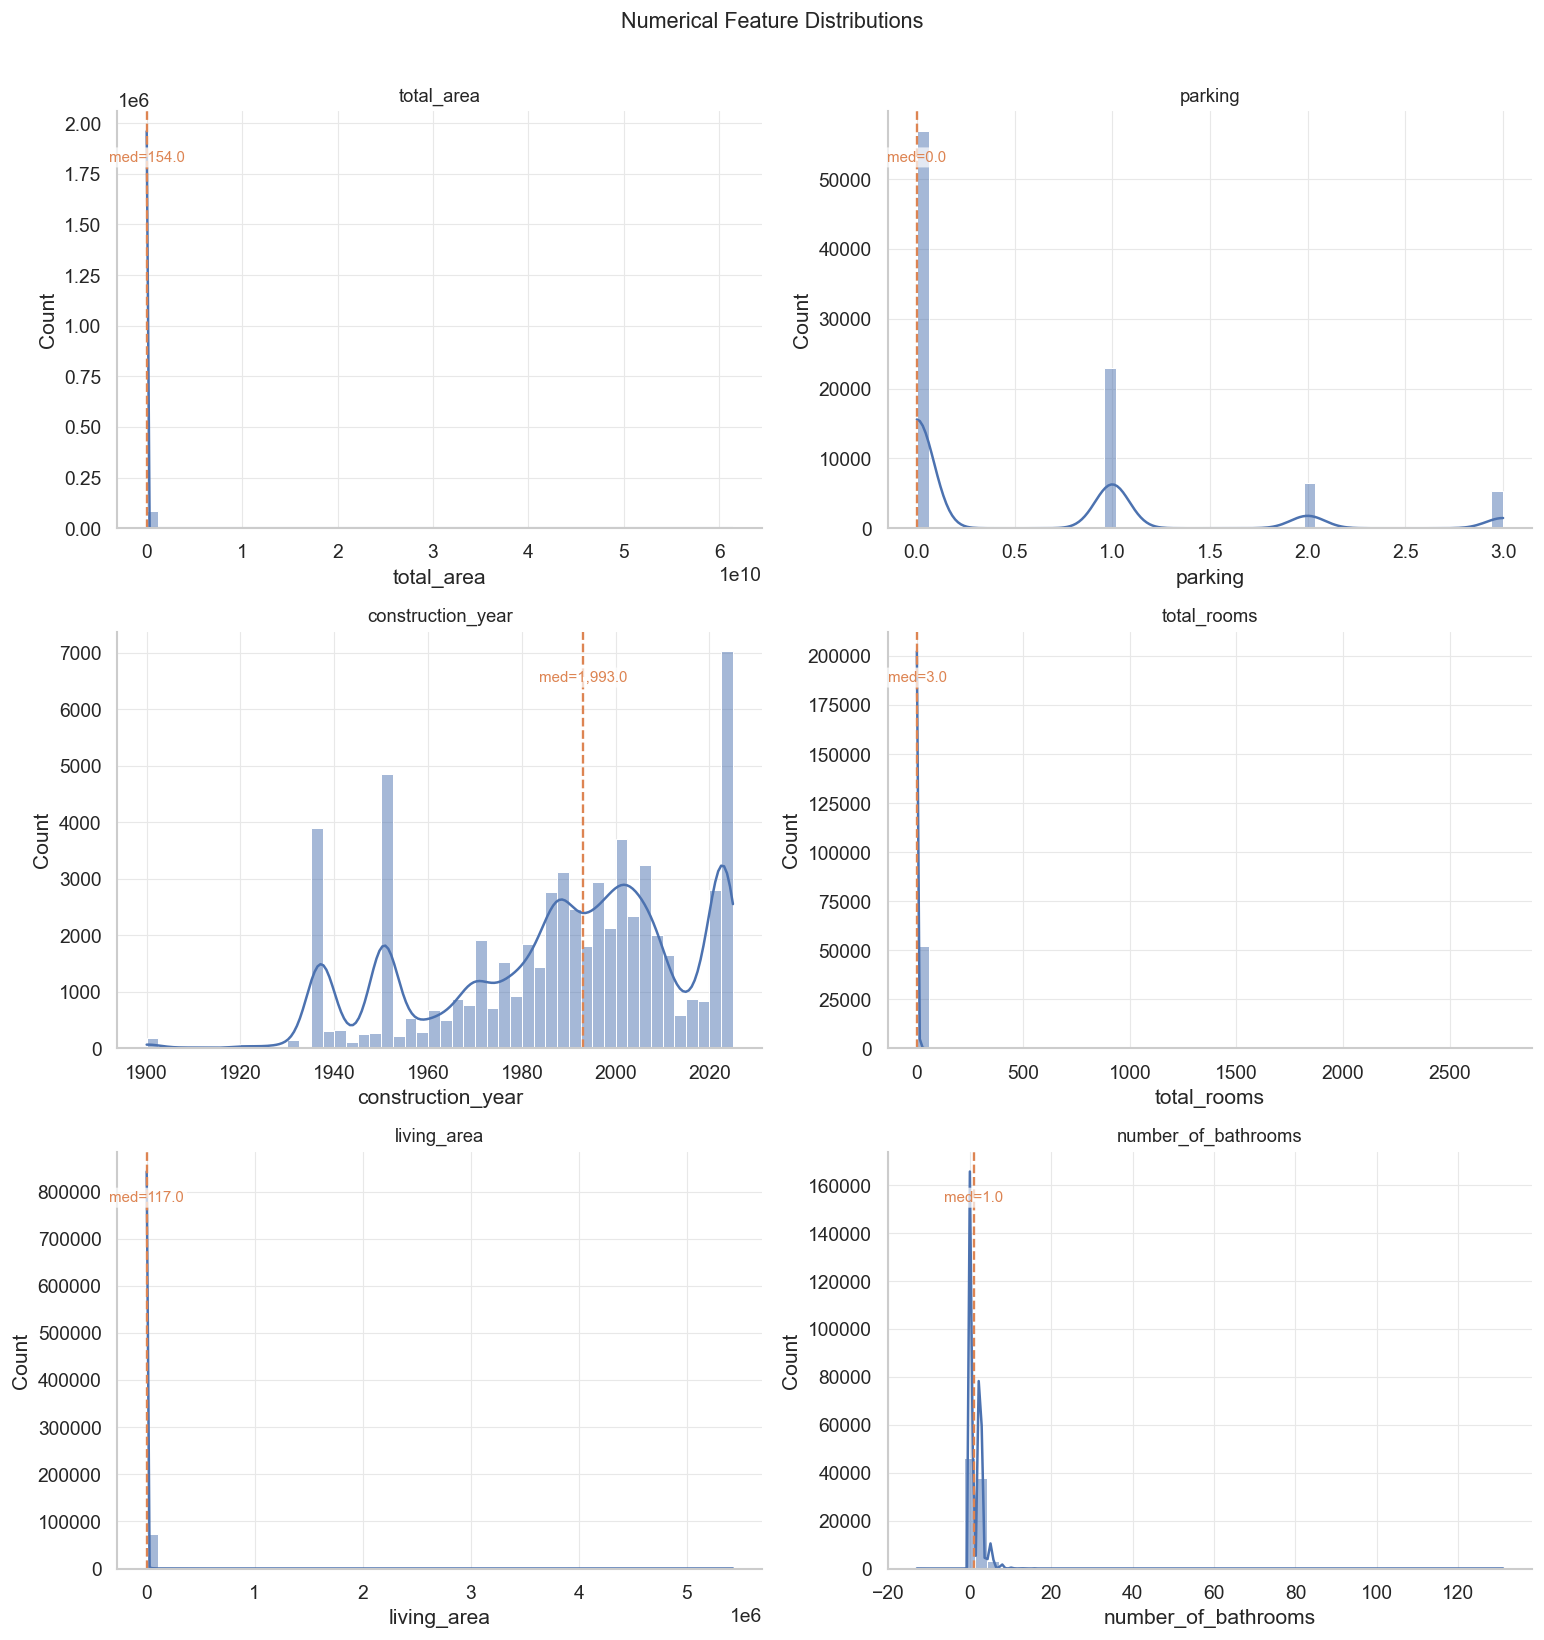

In [17]:
fig = plot_numerical_distributions(train_df, NUMERICAL_FEATURES)
plt.show()
save_figure(fig, "numerical_distributions", FIG_DIR / "eda")

- `total_area` is right-skewed. Most properties sit under 500 m² with a tail of large estates and land plots.
- `parking` is discrete and concentrated at 0 to 2 spaces.
- `construction_year` is bimodal, with peaks around 1970-1980 (the pre-1990 building wave) and 2010-2020 (recent development).
- `total_rooms` is right-skewed; most properties have 2 to 6 rooms.
- `living_area` looks like `total_area` but more concentrated.
- `number_of_bathrooms` is discrete, mostly 1 to 3.


### 6.3 SQL and Pandas querying

SQL handles set-level work cleanly: filtering, grouping, aggregation. Pandas is faster for row-level transforms and quick column math. I use both to show that the queries below are tool-agnostic, the choice is about which is more direct for the question.


In [18]:
con = duckdb.connect()
con.register("train", train_df)

#### Query 1 — Median price by district (SQL)

In [19]:
q1 = con.execute("""
    SELECT
        district,
        COUNT(*)                AS n,
        ROUND(MEDIAN(price), 0) AS median_price,
        ROUND(AVG(price), 0)    AS mean_price
    FROM train
    GROUP BY district
    ORDER BY median_price DESC
    LIMIT 10
""").df()
q1

,district,n,median_price,mean_price
0,Z - Fora de Portugal,5,560000.0,552000.0
1,Lisboa,22228,349000.0,519167.0
2,Faro,5652,310000.0,468740.0
3,Setúbal,8106,270000.0,397714.0
4,Porto,14826,250000.0,342348.0
5,Ilha de São Miguel,40,210000.0,354359.0
6,Braga,7670,189000.0,239726.0
7,Aveiro,4952,175000.0,246179.0
8,Évora,1769,167500.0,318354.0
9,Ilha do Faial,1,160000.0,160000.0


#### Query 2 — Median price by property type (SQL)

In [20]:
q2 = con.execute("""
    SELECT
        type,
        COUNT(*)                AS n,
        ROUND(MEDIAN(price), 0) AS median_price,
        ROUND(AVG(total_area), 1) AS avg_area
    FROM train
    WHERE type IN ('Apartment', 'House', 'Land', 'Store', 'Farm')
    GROUP BY type
    ORDER BY median_price DESC
""").df()
q2

,type,n,median_price,avg_area
0,Farm,2738,270000.0,167650.7
1,Apartment,32725,270000.0,2485.0
2,House,26870,248000.0,1961.1
3,Store,3294,134950.0,294.8
4,Land,19472,66500.0,4429125.6


#### Query 3 — Price by energy certificate (SQL)

In [21]:
q3 = con.execute("""
    SELECT
        energy_certificate,
        COUNT(*)                AS n,
        ROUND(MEDIAN(price), 0) AS median_price
    FROM train
    WHERE energy_certificate IS NOT NULL
    GROUP BY energy_certificate
    ORDER BY median_price DESC
""").df()
q3

,energy_certificate,n,median_price
0,A+,2777,438500.0
1,A,6424,434000.0
2,B,3041,408800.0
3,B-,3155,350000.0
4,C,11986,268500.0
5,D,11740,243900.0
6,E,8286,215000.0
7,Not available,12,212450.0
8,No Certificate,30,164250.0
9,F,5730,160000.0


#### Query 4 — Price per sqm by district (Pandas)

In [22]:
train_df["price_per_sqm"] = train_df["price"] / train_df["total_area"].replace(0, np.nan)
q4 = (
    train_df.groupby("district")["price_per_sqm"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_price_per_sqm", "count": "n"})
    .sort_values("median_price_per_sqm", ascending=False)
    .head(10)
    .round(0)
)
q4

,median_price_per_sqm,n
district,,
Lisboa,2915.0,21117
Faro,2444.0,5431
Setúbal,2143.0,7585
Z - Fora de Portugal,2029.0,5
Porto,1924.0,13914
Ilha do Faial,1168.0,1
Ilha das Flores,1154.0,1
Braga,1095.0,7034
Évora,901.0,1656


In [23]:
train_df = train_df.drop(columns=["price_per_sqm"])

#### Query 5 — Properties with vs without elevator (Pandas)

In [24]:
q5 = (
    train_df.groupby("elevator")["price"]
    .agg(["median", "mean", "count"])
    .rename(columns={"median": "median_price", "mean": "mean_price", "count": "n"})
    .round(0)
)
q5

,median_price,mean_price,n
elevator,,,
False,169500.0,303913.0,69263
True,320000.0,442421.0,22469


### 6.4 Query findings

Five things come out of the queries.

- Geographic premium. Lisboa has the highest median prices, with Faro and Setúbal close behind. Northern interior districts (Bragança, Vila Real) are well below.
- Property type pricing. Houses have higher median totals than apartments, but apartments often beat them on price per m² inside the cities.
- Energy efficiency premium. A+ and A certificates carry a clear price premium over C-F and NC.
- Elevator premium. Properties with elevators have substantially higher medians, almost certainly because the elevator flag is a proxy for newer construction in urban locations.
- Price per m². Lisboa leads here too, in line with capital-city pricing pressure.


### 6.5 Feature vs. target analysis


/Users/hussein-loubani/Turing College/Module 3/Sprint 2/portugal_housing/plots.py:223: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


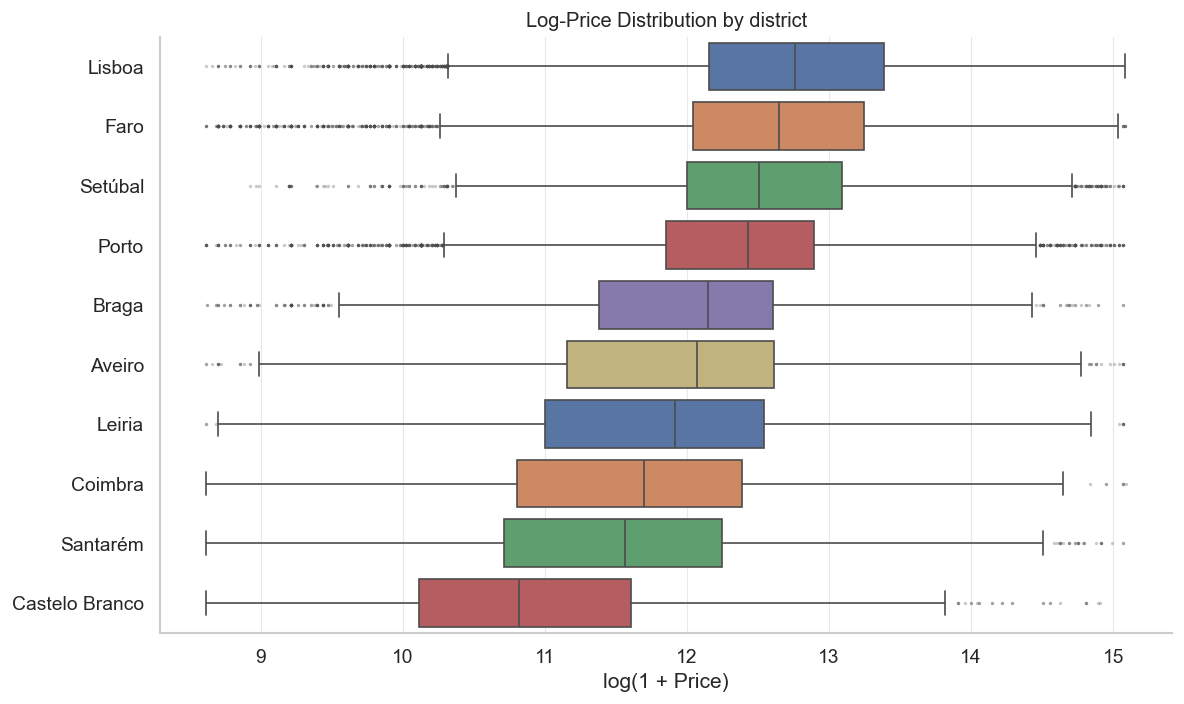

In [25]:
fig = plot_boxplots_by_category(train_df, "district", top_n=10)
plt.show()
save_figure(fig, "boxplots_by_district", FIG_DIR / "eda")

/Users/hussein-loubani/Turing College/Module 3/Sprint 2/portugal_housing/plots.py:223: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


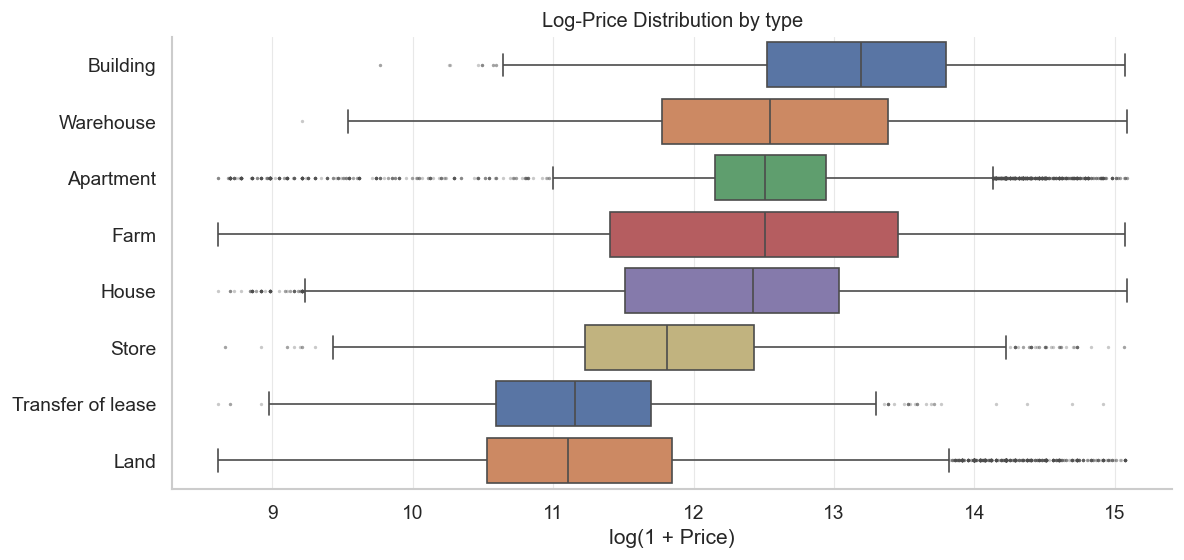

In [26]:
fig = plot_boxplots_by_category(train_df, "type", top_n=8)
plt.show()
save_figure(fig, "boxplots_by_type", FIG_DIR / "eda")

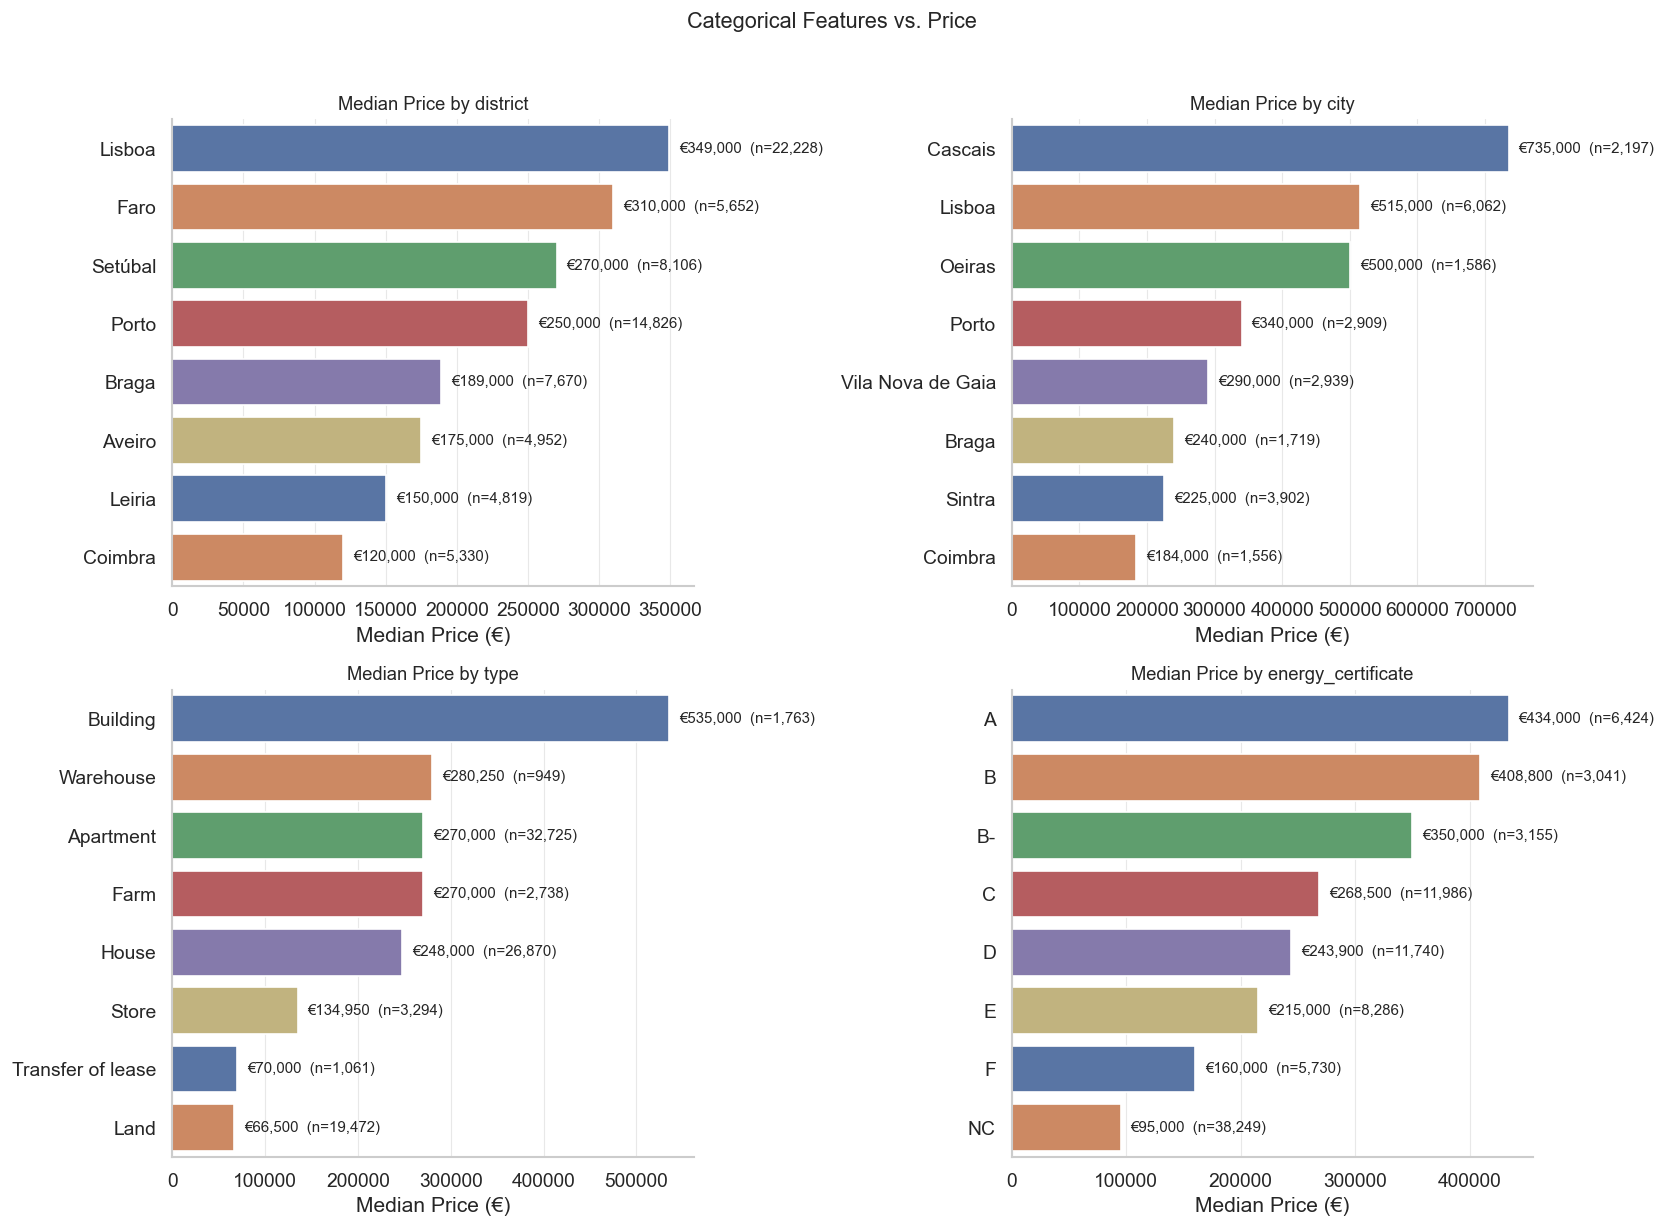

In [27]:
fig = plot_categorical_distributions(train_df, CATEGORICAL_FEATURES, top_n=8)
plt.show()
save_figure(fig, "categorical_distributions", FIG_DIR / "eda")

**Categorical findings.**

- `district` is a strong price predictor. Lisboa and Faro sit at the top of the distribution; interior districts cluster at the bottom.
- `type` separates pricing clearly. Larger residential and commercial categories rank high; utility types (Garage, Storage) sit at the bottom.
- `energy_certificate` shows a gradient. A+ and A properties carry a clear premium.


### 6.6 Correlation and association


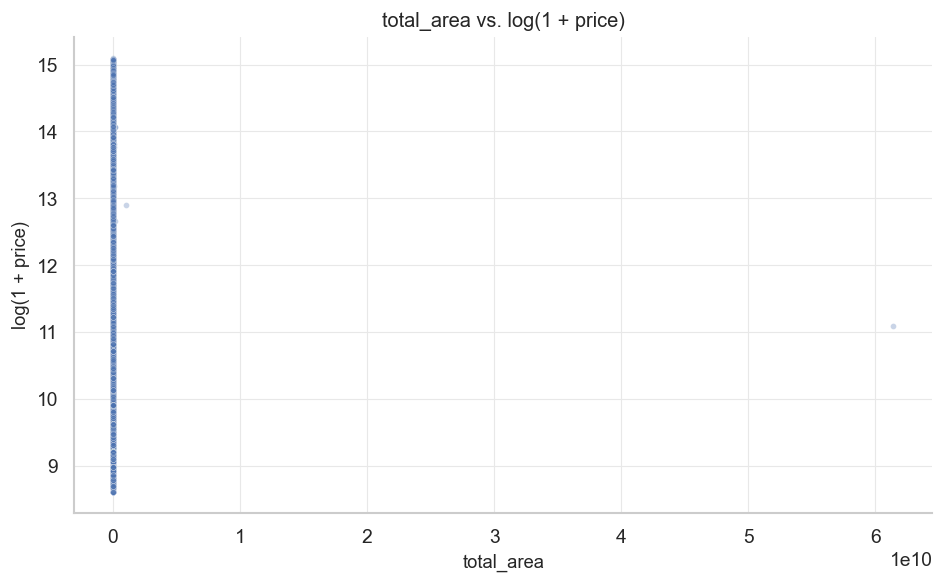

In [28]:
fig = plot_scatter(train_df, x="total_area", log_y=True)
plt.show()
save_figure(fig, "scatter_area_price", FIG_DIR / "eda")

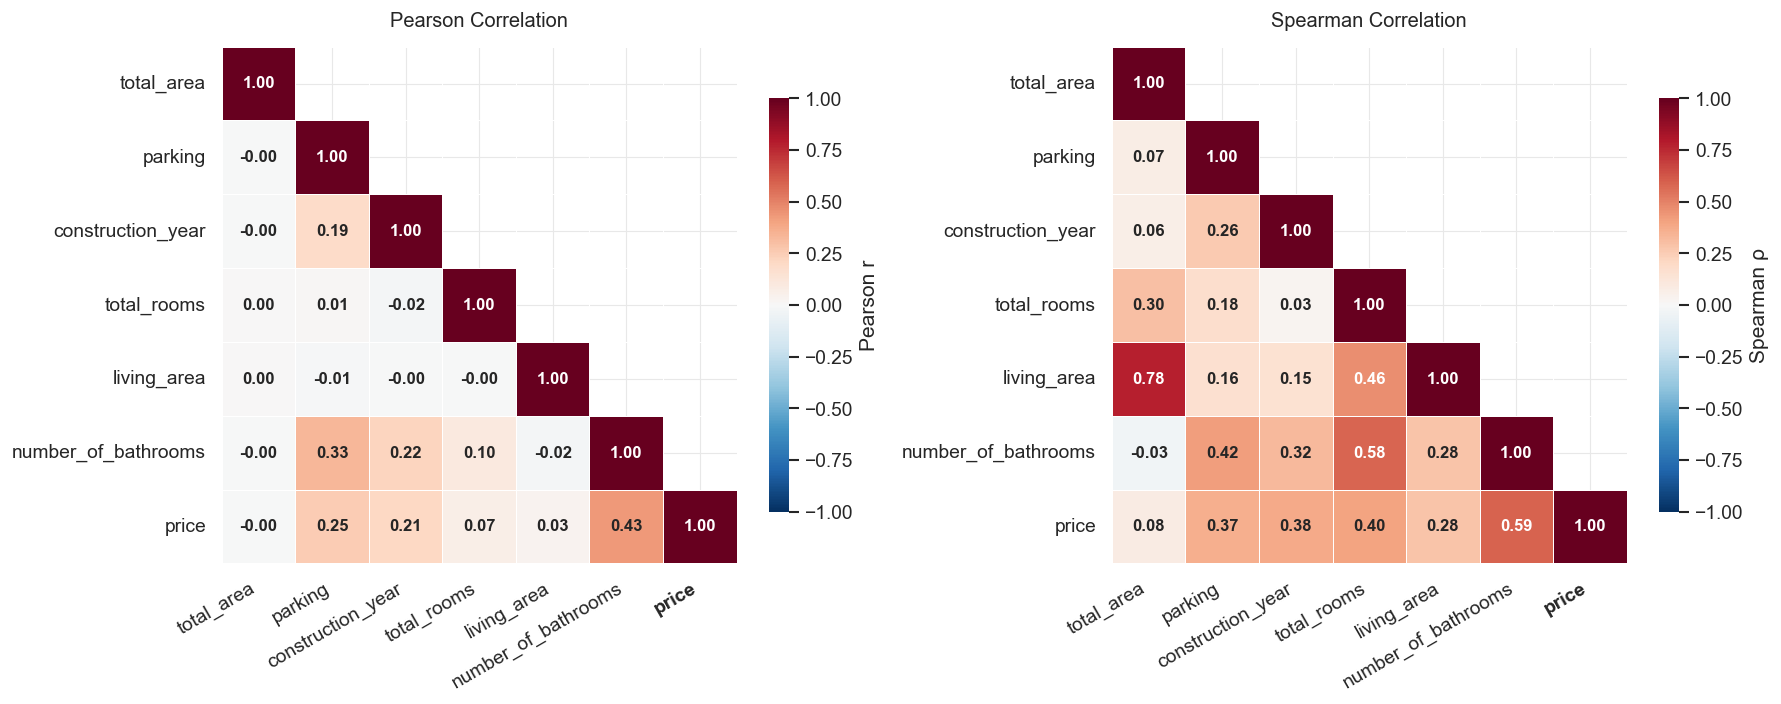

In [29]:
fig = plot_correlation_heatmap(train_df, NUMERICAL_FEATURES)
plt.show()
save_figure(fig, "correlation_heatmap", FIG_DIR / "eda")

**Correlation and association findings.**

- `total_area` and `living_area` correlate most strongly with price under both Pearson and Spearman. Size is the primary driver of listing price, which is what we expect.
- `number_of_bathrooms` and `total_rooms` also correlate positively, which is essentially the same effect: bigger properties have more rooms.
- `total_area` and `living_area` are highly correlated with each other. Tree-based models do not care, but linear models will need either regularization or one of them dropped.
- `construction_year` shows a weak positive association. Newer properties tend to be slightly more expensive on average, but the effect is small compared to area and location.


---
## 7. Statistical inference


### Population and sample

**Target population:** properties listed for sale on Portuguese real estate platforms.

**Sample:** the cleaned training split, roughly 91k listings scraped from several Portuguese property sites. This is not a random sample of the Portuguese housing stock. It is a convenience sample of whatever was listed and successfully scraped during the collection window.

**Representativeness risks:**

1. **Listing bias.** Only properties actively for sale appear. Owner-occupied homes that never reach the market are absent, and they may differ systematically in size, age, and location.
2. **Platform skew.** The source sites may over-represent certain agencies, regions, or price tiers.
3. **Asking price, not sale price.** Every figure here is what a seller asked, not what a buyer paid.
4. **Snapshot in time.** The data covers a single window. Interest rates and market conditions that move prices are not captured.

**Consequence for inference:** the tests below tell us whether differences are significant *within this sample of listings*. They do not generalize to the full Portuguese housing market, and they describe associations, not causes.

---

### Hypotheses

Three hypotheses, each motivated by the EDA and the business problem. Significance level α = 0.05 for all of them.

| # | Feature | H0 | H1 | Test |
|---|---|---|---|---|
| 1 | `district` | Mean price in Lisboa = mean price elsewhere | The two differ | Welch's t-test |
| 2 | `energy_certificate` | Mean price is equal across all certificate levels | At least one level differs | One-way ANOVA |
| 3 | `type` | Mean price of apartments = mean price of houses | The two differ | Welch's t-test |

### Hypothesis 1: Lisboa properties have significantly higher prices than other districts

| | Statement |
|---|---|
| **H0** | Mean price in Lisboa = mean price in other districts |
| **H1** | Mean price in Lisboa ≠ mean price in other districts |
| **α** | 0.05 |
| **Test** | Welch's two-sample t-test |

In [30]:
lisboa = train_df[train_df["district"] == "Lisboa"]["price"]
non_lisboa = train_df[train_df["district"] != "Lisboa"]["price"]

h1_result = two_sample_ttest(
    lisboa, non_lisboa,
    feature_name="price",
    h0="Mean price in Lisboa = mean price in other districts",
    h1="Mean price in Lisboa ≠ mean price in other districts",
)
print_test_result(h1_result)

──────────────────────────────────────────────────────────────
  Feature  : price
  H0       : Mean price in Lisboa = mean price in other districts
  H1       : Mean price in Lisboa ≠ mean price in other districts
  alpha    : 0.05

  Levene p-value : 0.0  (equal variance assumed: False)
  Group 0 mean   : 519,166.90  (n=22,228)
  Group 1 mean   : 279,834.00  (n=69,525)
  Difference     : 239,332.8988
  t-statistic    : 62.7613
  p-value    : 0.000000
  95% CI     : [231858.4895, 246807.3082]

  Verdict    : REJECT H0
──────────────────────────────────────────────────────────────


The t-test gives a clear rejection of H0. The 95% confidence interval for the difference in means does not contain zero, so the gap is not a sampling artifact. Lisboa being the capital, with concentrated demand and economic activity, is the obvious story.


### Hypothesis 2: Energy certificate rating is associated with price differences

| | Statement |
|---|---|
| **H0** | Mean price is equal across all energy certificate levels |
| **H1** | At least one energy certificate level has a different mean price |
| **α** | 0.05 |
| **Test** | One-way ANOVA |

In [31]:
cert_groups = []
cert_names  = []
for cert in ["A+", "A", "B", "B-", "C", "D", "E", "F"]:
    g = train_df[train_df["energy_certificate"] == cert]["price"].dropna()
    if len(g) >= 30:
        cert_groups.append(g)
        cert_names.append(cert)

h2_result = anova_test(
    cert_groups, cert_names,
    feature_name="price",
    h0="Mean price is equal across all energy certificate levels",
    h1="At least one energy certificate level has a different mean price",
)
print_test_result(h2_result)

──────────────────────────────────────────────────────────────
  Feature  : price
  H0       : Mean price is equal across all energy certificate levels
  H1       : At least one energy certificate level has a different mean price
  alpha    : 0.05

  A+                   : mean=572,762.53  (n=2,777)
  A                    : mean=595,062.88  (n=6,424)
  B                    : mean=590,539.28  (n=3,041)
  B-                   : mean=531,641.71  (n=3,155)
  C                    : mean=396,015.87  (n=11,986)
  D                    : mean=353,107.90  (n=11,740)
  E                    : mean=315,872.15  (n=8,286)
  F                    : mean=261,836.30  (n=5,730)
  Levene p-value : 0.0  (equal variance assumed: False)
  F-statistic    : 555.3878
  p-value    : 0.000000

  Verdict    : REJECT H0
──────────────────────────────────────────────────────────────


ANOVA rejects H0 with a very small p-value. Energy certificate level is associated with significant price differences, with A+ and A properties asking the most. The premium probably reflects two things at once: the direct value of efficiency, and the fact that high ratings tend to come with newer buildings.


### Hypothesis 3: Apartments and houses have significantly different prices

| | Statement |
|---|---|
| **H0** | Mean price of apartments = mean price of houses |
| **H1** | Mean price of apartments ≠ mean price of houses |
| **α** | 0.05 |
| **Test** | Welch's two-sample t-test |

In [32]:
apt_prices   = train_df[train_df["type"] == "Apartment"]["price"]
house_prices = train_df[train_df["type"] == "House"]["price"]

h3_result = two_sample_ttest(
    apt_prices, house_prices,
    feature_name="price",
    h0="Mean price of apartments = mean price of houses",
    h1="Mean price of apartments ≠ mean price of houses",
)
print_test_result(h3_result)

──────────────────────────────────────────────────────────────
  Feature  : price
  H0       : Mean price of apartments = mean price of houses
  H1       : Mean price of apartments ≠ mean price of houses
  alpha    : 0.05

  Levene p-value : 0.0  (equal variance assumed: False)
  Group 0 mean   : 369,384.55  (n=32,725)
  Group 1 mean   : 379,252.77  (n=26,870)
  Difference     : -9,868.2183
  t-statistic    : -2.9891
  p-value    : 0.002800
  95% CI     : [-16339.1086, -3397.3280]

  Verdict    : REJECT H0
──────────────────────────────────────────────────────────────


The test rejects H0. Houses ask more on average than apartments, which mostly tracks their larger size. Once we control for area (price per m²), the relationship can flip in dense urban centers where apartment land is at a premium.


### Statistical inference findings

- **H1 — Lisboa premium (Welch's t-test):** H0 rejected. Lisboa listings ask significantly more than the rest of the country, and the 95% confidence interval for the gap excludes zero. District is confirmed as a first-order price driver.
- **H2 — Energy certificate (one-way ANOVA):** H0 rejected. Mean price differs across certificate levels, with the A+/A tiers well above C/D/NC. Part of this is the efficiency itself and part is its correlation with newer construction.
- **H3 — Apartment vs house (Welch's t-test):** H0 rejected. Houses ask more on average, largely tracking their larger size. The relationship can invert on a price-per-m² basis in dense urban areas.

All three features are kept for modeling. The tests confirm they carry real signal; the models decide how much weight each one gets.

---
## 8. Preprocessing strategy


### 8.1 Feature typing and treatment plan

| Feature | Type | Treatment |
|---------|------|-----------|
| total_area | Numerical | StandardScaler |
| parking | Numerical | StandardScaler |
| construction_year | Numerical | StandardScaler |
| total_rooms | Numerical | StandardScaler |
| living_area | Numerical | StandardScaler |
| number_of_bathrooms | Numerical | StandardScaler |
| elevator | Binary | Passthrough (already bool) |
| type | Categorical (low card.) | OneHotEncoder (drop='first') |
| energy_certificate | Categorical (low card.) | OneHotEncoder (drop='first') |
| district | Categorical (medium card.) | OneHotEncoder (drop='first', min_frequency=50) |
| city | Categorical (high card.) | Dropped (too many levels) |
| town | Categorical (high card.) | Dropped (too many levels) |

### 8.2 Feature engineering


In [33]:
train_eng = add_engineered_features(train_df)
print("New engineered features (first 5 rows):")
train_eng[["property_age", "log_total_area", "log_living_area"]].head()

New engineered features (first 5 rows):


,property_age,log_total_area,log_living_area
0,18.0,NaN,NaN
1,NaN,4.955827,4.812184
2,25.0,4.875197,4.875197
3,17.0,4.905275,4.905275
4,68.0,2.890372,2.772589


**Feature engineering notes.**

- `property_age` is `2026 - construction_year`. It captures the age effect more directly than the raw year, which is convenient for linear models. Missing construction years stay as NaN and are handled by the imputer.
- `log_total_area` and `log_living_area` use `log1p`. The transform pulls in the long tail and linearises the area-price relationship for regression-based models.
- `price_per_sqm` was useful in EDA (Query 4) but is excluded from modeling features. It is a function of the target and would leak.


### 8.3 Preprocessing pipeline

Preprocessing is one sklearn `ColumnTransformer` wrapped in a `Pipeline` factory (`make_pipeline`). Every call returns a fresh, unfitted pipeline, which keeps cross-validation honest: the transformer is only ever fitted on the training fold.


### 8.4 Dimensionality reduction


In [34]:
X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

In [35]:
pre_fitted = build_preprocessor().fit(X_train)
X_tr = pre_fitted.transform(X_train)
print(f"Preprocessed shape: {X_tr.shape}")

Preprocessed shape: (91753, 52)


In [36]:
pca = PCA().fit(X_tr)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n95 = np.argmax(cumvar >= 0.95) + 1
n99 = np.argmax(cumvar >= 0.99) + 1
print(f"Components for 95% variance: {n95}")
print(f"Components for 99% variance: {n99}")
print(f"Total components: {X_tr.shape[1]}")

Components for 95% variance: 20
Components for 99% variance: 33
Total components: 52


**PCA findings.**

PCA is here for diagnostics, not for modeling. The number of components needed to hit 95% variance gives a sense of how much redundancy the OHE expansion introduces.

I do not feed PCA components into the final models. Tree-based models work directly on the sparse encoded features and gain nothing from PCA's rotation, so the full feature set goes through.


---
## 9. Baseline models


In [37]:
dummy_pipe = make_pipeline(DummyRegressor(strategy="mean"))
lr_pipe    = make_pipeline(LinearRegression())
ridge_pipe = make_pipeline(Ridge(alpha=1.0, random_state=RANDOM_SEED))
lasso_pipe = make_pipeline(Lasso(alpha=1.0, random_state=RANDOM_SEED, max_iter=5000))

baseline_pipelines = {
    "Dummy (mean)":       dummy_pipe,
    "Linear Regression":  lr_pipe,
    "Ridge":              ridge_pipe,
    "Lasso":              lasso_pipe,
}

baseline_cv = cv_compare(baseline_pipelines, X_train, y_train)
baseline_cv

,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
Linear Regression,-388711.2538,81948.0352,-339359.7933,0.39
Lasso,-388731.5822,81962.2064,-339359.8113,1.11
Ridge,-388917.2046,82105.1301,-339360.4230,0.36
Dummy (mean),-420773.1986,6649.2694,-420811.8021,0.29


**Baseline findings.**

The dummy regressor (always predict the mean price) sets the floor. Anything we deploy needs to beat it by a wide margin, otherwise we are paying for compute to reproduce a one-line script.

Linear Regression, Ridge, and Lasso give the linear baseline. The gap between these and the tree-based models in Section 10 tells us how much of the price signal is non-linear: a small gap means most of the signal is linear, a large gap means interactions and non-linearities matter.


---
## 10. Model comparison with cross-validation


In [38]:
candidate_pipelines = {
    "Decision Tree":      make_pipeline(DecisionTreeRegressor(random_state=RANDOM_SEED)),
    "Random Forest":      make_pipeline(RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)),
    "Gradient Boosting":  make_pipeline(GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_SEED)),
    "XGBoost":            make_pipeline(xgb.XGBRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)),
    "LightGBM":           make_pipeline(lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)),
}

cv_results = cv_compare(candidate_pipelines, X_train, y_train)
cv_results

,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
Random Forest,-269843.0200,4044.8999,-125632.5647,19.39
XGBoost,-273428.3556,5541.7990,-235613.2988,0.69
LightGBM,-279214.9668,5928.1137,-264456.7812,2.00
Gradient Boosting,-298464.0287,5919.4051,-294232.9125,11.93
Decision Tree,-351760.0489,7530.6345,-81440.4891,0.72


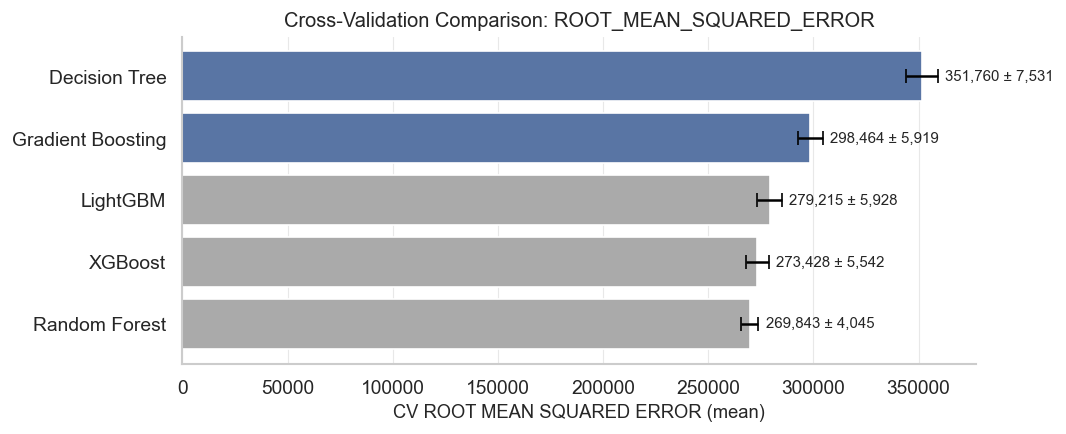

In [39]:
fig = plot_cv_comparison(cv_results)
plt.show()
save_figure(fig, "cv_comparison_baseline", FIG_DIR / "model_comparison")

**Reading the comparison.**

Mean CV RMSE is the primary ranking criterion. Lower is better, and a high standard deviation across folds is a warning that the model is unstable on this data.

A few patterns to expect:

- A single decision tree usually overfits hard. Train error is near zero, validation error is much higher, because nothing stops it from memorizing.
- Random Forest cuts variance through bagging. Each tree sees a bootstrap sample and a random feature subset, then predictions are averaged.
- Gradient Boosting, XGBoost, and LightGBM cut both bias and variance through sequential boosting. Each new tree fits the residual of the previous ensemble.

### Bagging vs. boosting

| Aspect | Bagging (Random Forest) | Boosting (GBM, XGBoost, LightGBM) |
|--------|-------------------------|-------------------------------------|
| Training | Trees trained independently in parallel | Trees trained sequentially, each correcting prior errors |
| Goal | Reduce variance | Reduce bias and variance |
| Aggregation | Average of all tree predictions | Weighted sum of sequential corrections |
| Overfitting risk | Lower (averaging dampens variance) | Higher (sequential fitting can chase noise) |
| Key regularizer | `max_features`, `n_estimators` | `learning_rate`, `max_depth`, `subsample` |

Which one wins on this data is an empirical question. If variance was the main problem, bagging would lead. If bias and complex interactions matter more, boosting wins.


---
## 11. Hyperparameter tuning


In [40]:
xgb_grid_search = GridSearchCV(
    make_pipeline(xgb.XGBRegressor(random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)),
    param_grid=XGB_GRID,
    cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1, refit=True,
)
xgb_grid_search.fit(X_train, y_train)
print(f"Best XGBoost params: {xgb_grid_search.best_params_}")
print(f"Best CV RMSE: {-xgb_grid_search.best_score_:,.0f}")

Best XGBoost params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 400, 'clf__subsample': 0.8}
Best CV RMSE: 265,543


In [41]:
lgbm_grid_search = GridSearchCV(
    make_pipeline(lgb.LGBMRegressor(random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)),
    param_grid=LGBM_GRID,
    cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1, refit=True,
)
lgbm_grid_search.fit(X_train, y_train)
print(f"Best LightGBM params: {lgbm_grid_search.best_params_}")
print(f"Best CV RMSE: {-lgbm_grid_search.best_score_:,.0f}")

Best LightGBM params: {'clf__learning_rate': 0.1, 'clf__min_child_samples': 10, 'clf__n_estimators': 400, 'clf__num_leaves': 63}
Best CV RMSE: 265,929


In [42]:
rf_grid_search = GridSearchCV(
    make_pipeline(RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)),
    param_grid=RF_GRID,
    cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1, refit=True,
)
rf_grid_search.fit(X_train, y_train)
print(f"Best RF params: {rf_grid_search.best_params_}")
print(f"Best CV RMSE: {-rf_grid_search.best_score_:,.0f}")

Best RF params: {'clf__max_depth': 20, 'clf__max_features': 0.5, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best CV RMSE: 261,886


In [43]:
tuned_pipelines = {
    "XGBoost (tuned)":   xgb_grid_search.best_estimator_,
    "LightGBM (tuned)":  lgbm_grid_search.best_estimator_,
    "RF (tuned)":        rf_grid_search.best_estimator_,
}
tuned_cv = cv_compare(tuned_pipelines, X_train, y_train)
tuned_cv

,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
RF (tuned),-261886.3459,4864.0705,-160209.8394,14.68
XGBoost (tuned),-265542.6455,4940.0942,-203053.1627,2.10
LightGBM (tuned),-265928.8482,5467.1477,-205083.6874,12.23


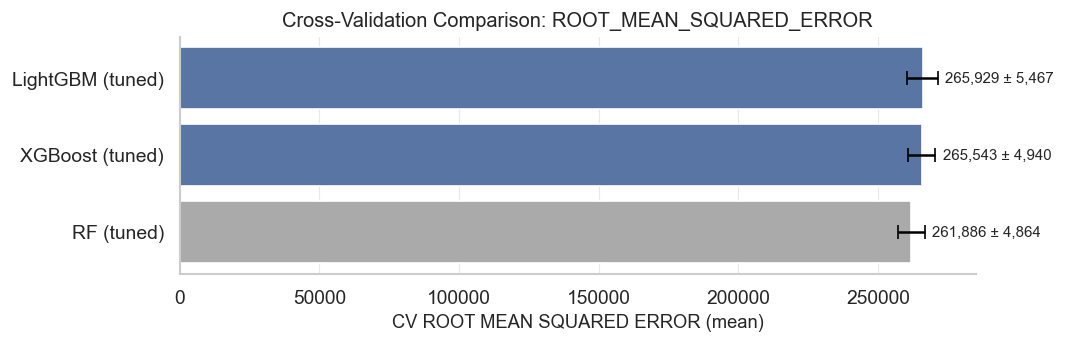

In [44]:
fig = plot_cv_comparison(tuned_cv)
plt.show()
save_figure(fig, "cv_comparison_tuned", FIG_DIR / "hyperparameter_tuning")

**Tuning findings.**

Tuning usually closes the gap between training and validation scores rather than dramatically improving the leaderboard. A few specifics for this run:

- XGBoost and LightGBM respond most to `learning_rate`, `max_depth`, and the regularization parameters. A lower learning rate paired with more estimators usually generalizes better.
- Random Forest is mostly about `max_depth` and `max_features` to keep individual trees from getting too greedy.

The post-tuning leaderboard tells us whether the ranking from Section 10 holds up, or whether tuning shifted who is on top.


---
## 12. Ensemble methods


In [45]:
voting_reg = VotingRegressor(
    estimators=[
        ("xgb",  xgb_grid_search.best_estimator_),
        ("lgbm", lgbm_grid_search.best_estimator_),
        ("rf",   rf_grid_search.best_estimator_),
    ],
)

stacking_reg = StackingRegressor(
    estimators=[
        ("xgb",  xgb_grid_search.best_estimator_),
        ("lgbm", lgbm_grid_search.best_estimator_),
        ("rf",   rf_grid_search.best_estimator_),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=CV,
    n_jobs=-1,
)

ensemble_pipelines = {
    "Voting (avg)":          voting_reg,
    "Stacking (Ridge meta)": stacking_reg,
}
all_pipelines = {**tuned_pipelines, **ensemble_pipelines}
ensemble_cv = cv_compare(all_pipelines, X_train, y_train)
ensemble_cv

,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
Stacking (Ridge meta),-258734.8221,5007.1540,-174771.5712,133.34
Voting (avg),-259540.7308,5183.8493,-184744.9655,29.96
RF (tuned),-261886.3459,4864.0705,-160209.8394,14.63
XGBoost (tuned),-265542.6455,4940.0942,-203053.1627,2.30
LightGBM (tuned),-265928.8482,5467.1477,-205083.6874,13.21


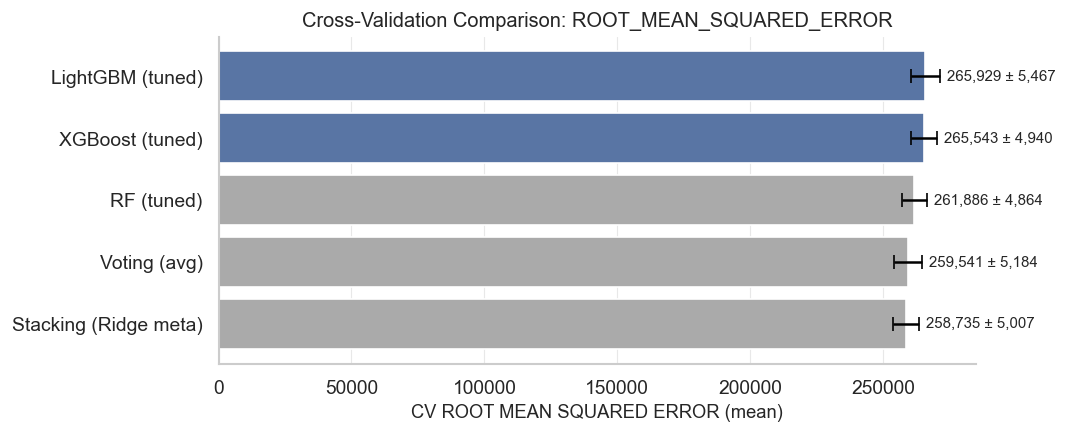

In [46]:
fig = plot_cv_comparison(ensemble_cv)
plt.show()
save_figure(fig, "cv_comparison_ensemble", FIG_DIR / "model_comparison")

**Ensemble findings.**

- VotingRegressor averages the three tuned models. It tends to give more stable predictions than any single model because the averaging cancels out fold-specific quirks.
- StackingRegressor uses a Ridge meta-learner to learn how much weight to put on each base model. This pays off when base models make different *kinds* of errors that complement each other.

The comparison shows whether the ensemble actually beats the best single model. Even a small RMSE improvement is worth carrying into production, since the cost of voting at inference time is negligible.


---
## 13. Final test evaluation


In [47]:
final_models = {
    "XGBoost (tuned)":       xgb_grid_search.best_estimator_,
    "LightGBM (tuned)":      lgbm_grid_search.best_estimator_,
    "RF (tuned)":            rf_grid_search.best_estimator_,
}

best_ensemble = voting_reg
best_ensemble.fit(X_train, y_train)
final_models["Ensemble"] = best_ensemble

all_metrics = {}
for name, model in final_models.items():
    all_metrics[name] = evaluate_model(model, X_test, y_test, model_name=name)


  XGBoost (tuned): Test Set Evaluation
  RMSE            : €266,164.81
  MAE             : €137,278.07
  R²              : 0.6051
  MAPE            : 90.32%
  Residual mean   : €2,605.39
  Residual std    : €266,157.86

  LightGBM (tuned): Test Set Evaluation
  RMSE            : €263,403.11
  MAE             : €136,525.77
  R²              : 0.6132
  MAPE            : 89.74%
  Residual mean   : €2,179.35
  Residual std    : €263,399.83



  RF (tuned): Test Set Evaluation
  RMSE            : €263,359.01
  MAE             : €131,210.93
  R²              : 0.6134
  MAPE            : 91.35%
  Residual mean   : €332.89
  Residual std    : €263,364.54



  Ensemble: Test Set Evaluation
  RMSE            : €259,787.43
  MAE             : €132,100.23
  R²              : 0.6238
  MAPE            : 88.11%
  Residual mean   : €1,705.87
  Residual std    : €259,787.49


In [48]:
print("Final test set comparison (sorted by RMSE):")
compare_final_metrics(all_metrics)

Final test set comparison (sorted by RMSE):


,rmse,mae,r2,mape,residual_mean,residual_std
model,,,,,,
Ensemble,259787.43,132100.23,0.6238,0.8811,1705.87,259787.49
RF (tuned),263359.01,131210.93,0.6134,0.9135,332.89,263364.54
LightGBM (tuned),263403.11,136525.77,0.6132,0.8974,2179.35,263399.83
XGBoost (tuned),266164.81,137278.07,0.6051,0.9032,2605.39,266157.86


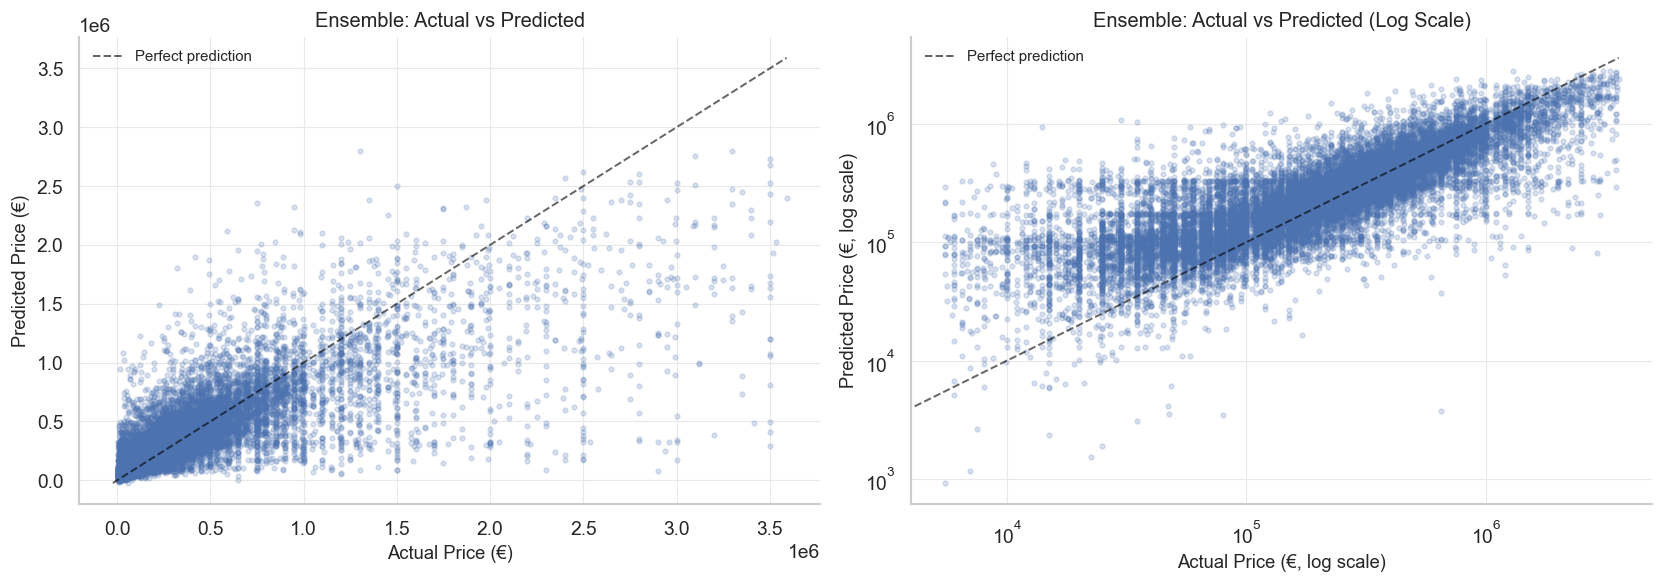

In [49]:
top_model_name = compare_final_metrics(all_metrics).index[0]
top_model      = final_models[top_model_name]
top_preds      = all_metrics[top_model_name]["y_pred"]

fig = plot_actual_vs_predicted(y_test, top_preds, top_model_name)
plt.show()
save_figure(fig, "actual_vs_predicted_top", FIG_DIR / "final_evaluation")

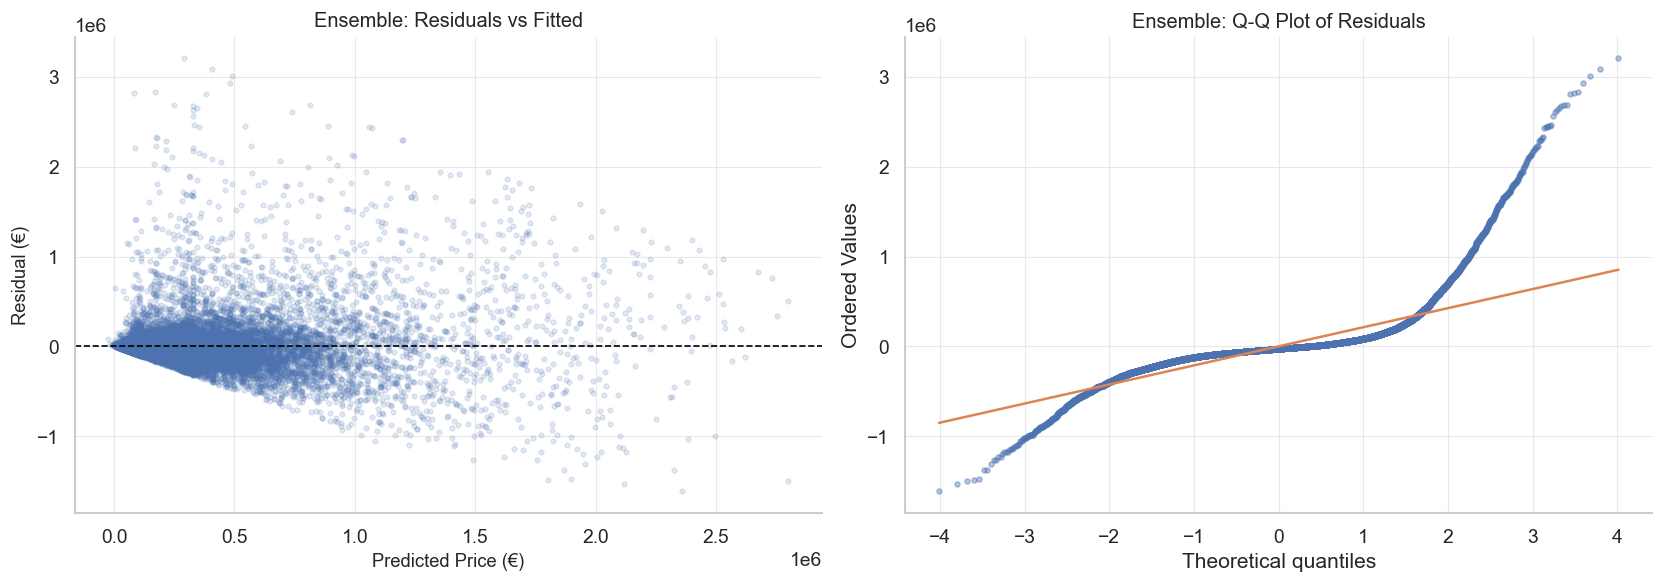

In [50]:
fig = plot_residuals(y_test, top_preds, top_model_name)
plt.show()
save_figure(fig, "residuals_top", FIG_DIR / "final_evaluation")

**Final evaluation interpretation.**

- The actual-vs-predicted scatter is the headline plot. Points along the diagonal are accurate predictions; spread away from it shows where the model misses.
- The log-scale view tells us whether the model behaves consistently across price bands or breaks down at the high end. Very expensive listings are typically the hardest segment.
- Residual diagnostics: the residuals-vs-fitted plot checks for heteroscedasticity, and the Q-Q plot checks tail behavior. Heavy tails are normal for price data and acceptable for tree-based models, which do not assume Gaussian residuals.


---
## 14. Error analysis and interpretation


### 14.1 SHAP and feature importance

In [51]:
# LightGBM is used for the SHAP analysis. SHAP's TreeExplainer is fully
# compatible with it; the installed XGBoost stores base_score in a format
# the current SHAP version cannot parse.
best_tree = lgbm_grid_search.best_estimator_
pre = best_tree.named_steps["pre"]
clf = best_tree.named_steps["clf"]

# Transform to the model's input space; cast to float so SHAP accepts it
X_train_transformed = pre.transform(X_train).astype(float)
X_test_transformed  = pre.transform(X_test).astype(float)
feature_names = pre.get_feature_names_out().tolist()

# TreeExplainer is the fast, exact explainer for gradient-boosted trees
explainer = shap.TreeExplainer(clf, feature_names=feature_names)
shap_values = explainer(X_test_transformed)

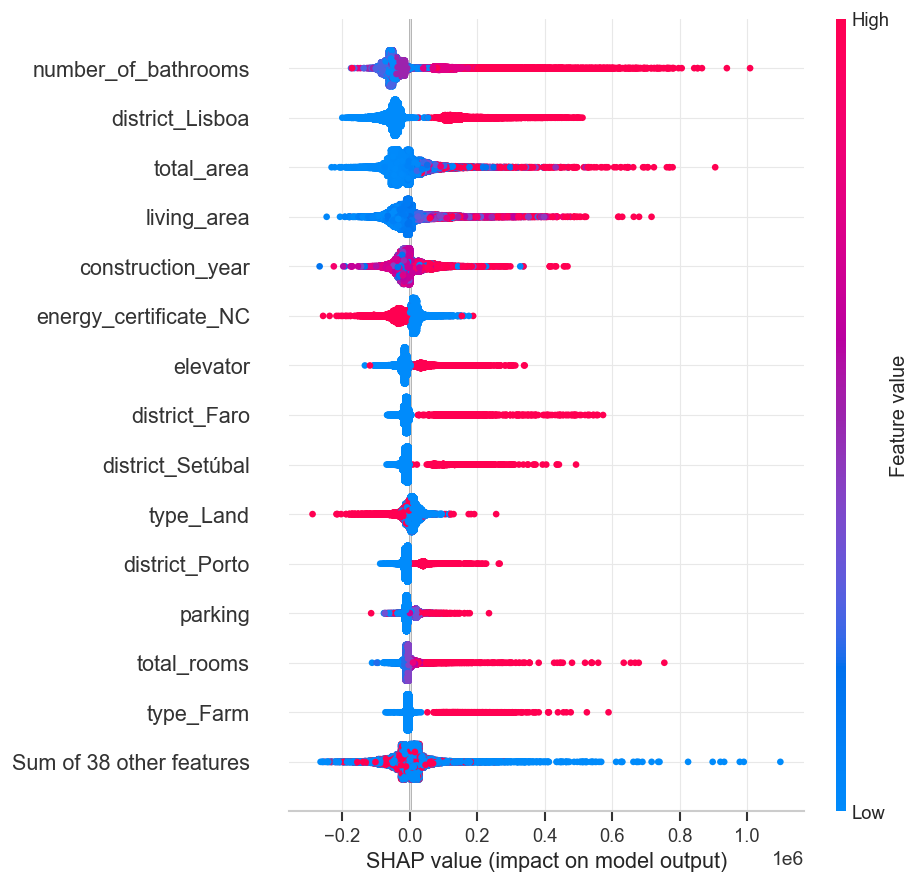

In [52]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
fig_shap = plt.gcf()
fig_shap.tight_layout()
plt.show()
save_figure(fig_shap, "shap_beeswarm", FIG_DIR / "error_analysis")

**SHAP beeswarm interpretation.**

Each dot is one test sample. Horizontal position is the SHAP value (impact on the prediction in log-price units). Color encodes the feature value (red = high, blue = low). Features are ranked top-to-bottom by mean absolute SHAP, so the most influential drivers are at the top.

This is the global view: it tells us which features matter and in which direction.


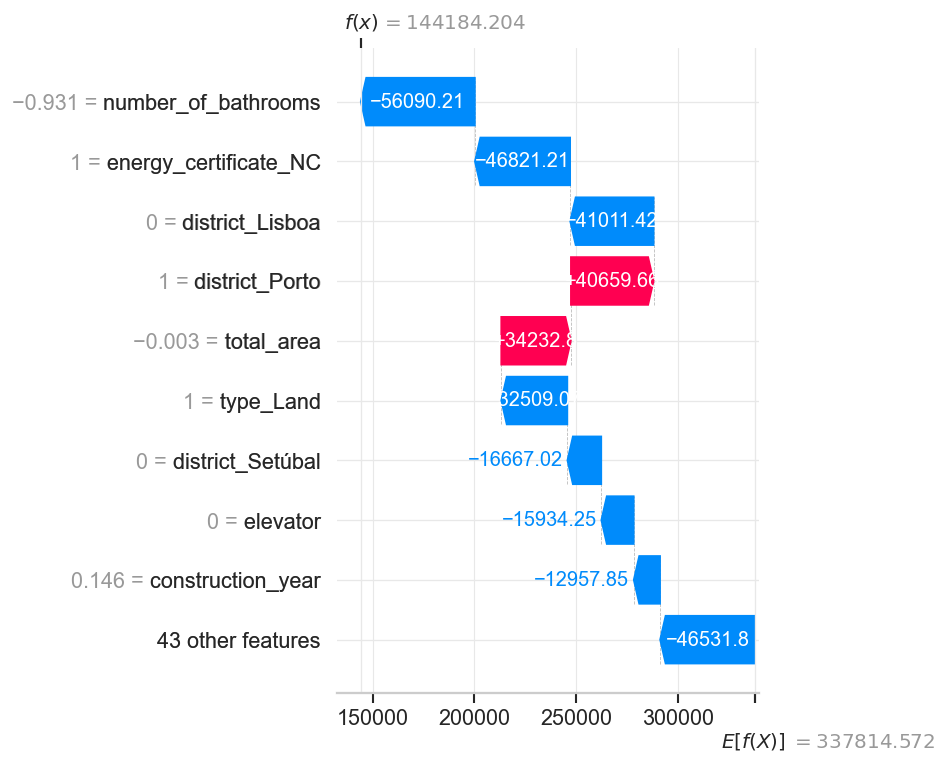

In [53]:
idx = 0
shap.plots.waterfall(shap_values[idx], show=False)
fig_wf = plt.gcf()
fig_wf.tight_layout()
plt.show()
save_figure(fig_wf, "shap_waterfall", FIG_DIR / "error_analysis")

**SHAP waterfall interpretation.**

This plot explains a single prediction. Each bar shows how one feature pushed the prediction up or down from the base value (the mean prediction across the dataset). Red bars push up, blue bars push down.

For the use case here, the per-prediction explanation is the important part. A broker is not going to call an owner because "the model says so". They need a defensible reason, and the waterfall plot gives them one: this listing looks underpriced because area X and location Y normally indicate a higher price.


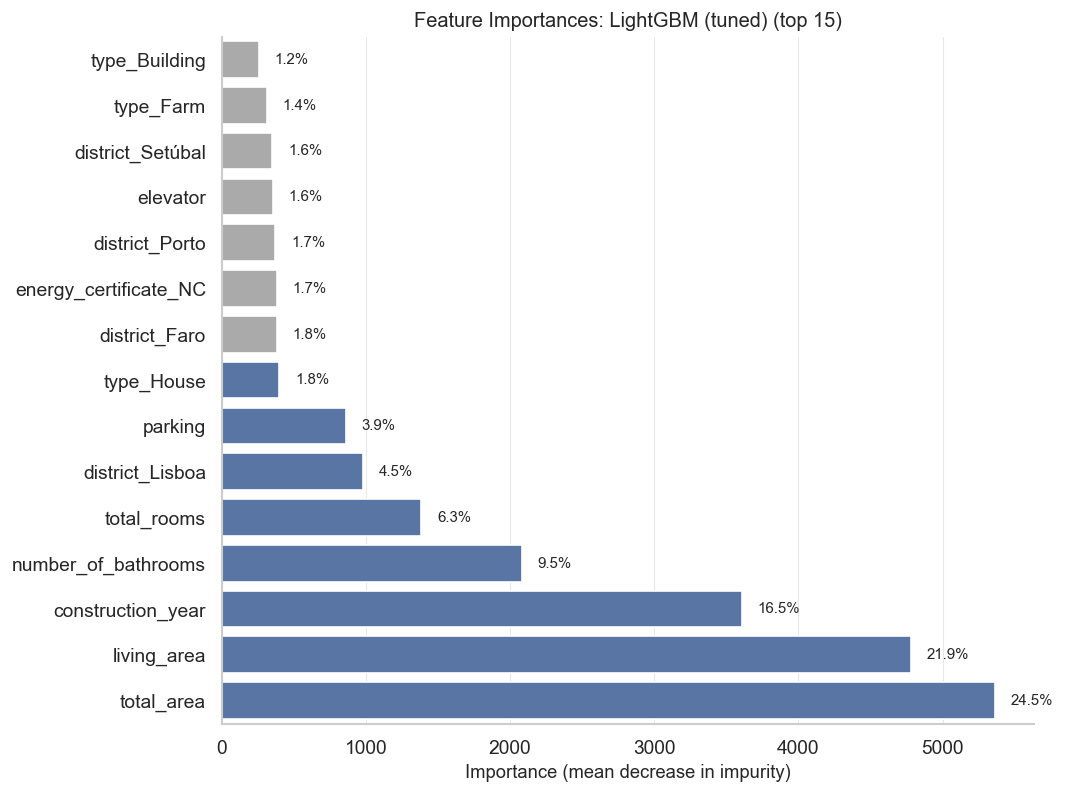

In [54]:
fig = plot_feature_importance(feature_names, clf.feature_importances_, "LightGBM (tuned)")
plt.show()
save_figure(fig, "feature_importance", FIG_DIR / "error_analysis")

### 14.2 Learning curve: overfitting check


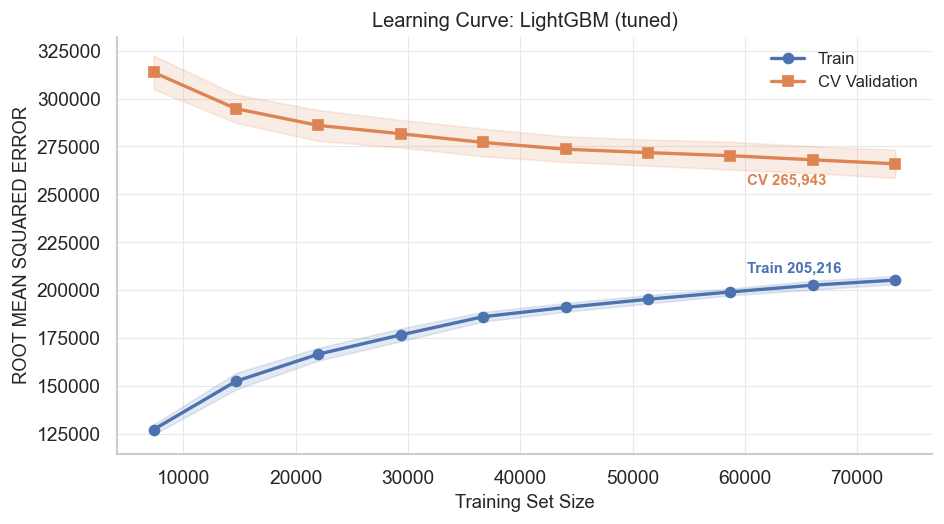

In [55]:
fig = plot_learning_curve(best_tree, X_train, y_train, "LightGBM (tuned)")
plt.show()
save_figure(fig, "learning_curve", FIG_DIR / "error_analysis")

**Learning curve findings.**

Three patterns to watch for:

- Curves that converge as training size grows. The model has roughly enough data and is not severely overfitting.
- A persistent train-vs-validation gap. Classic overfitting. Either more data, stronger regularization, or a simpler model would help.
- Both curves plateauing well before the dataset is exhausted. Diminishing returns from more rows. Better features or a more expressive model is the next lever.


---
## 15. Deployment


### Batch vs. real-time inference

| Mode | When to use | How it works |
|------|-------------|--------------|
| Batch inference | Scheduled scoring of many records (for example, a nightly scan of new listings) | Read CSV, predict all rows, write results |
| Real-time inference | Immediate prediction for a single listing (for example, when a new property is uploaded) | HTTP POST with features, instant price prediction |

The business requirement here is real-time: brokers want predictions the moment a new listing appears, so the primary deployment is a REST API. The batch script is included for backfills and ad-hoc scoring of historical data.


### Choosing the deployment model

The Ensemble wins on test RMSE, but the margin over the tuned LightGBM is about 1.4% and the ensemble serializes to roughly 800 MB because of the deep Random Forest inside it. That will not fit in a 512 MB Cloud Run container, and it would make every cold start slow.

LightGBM is the production choice: near-identical accuracy, a few MB on disk, and fast load times. Trading 1.4% RMSE for a 100x smaller, faster-loading artifact is the right call for a real-time pricing API.


In [56]:
# The Ensemble has the best test RMSE, but it bundles a deep Random Forest and
# weighs ~800 MB once serialized, too large for a 512 MB Cloud Run container.
# LightGBM is within ~1.4% on RMSE, loads in milliseconds, and serializes to a
# few MB. For a real-time API the size and latency win easily, so LightGBM is
# the deployment model.
deployment_model = lgbm_grid_search.best_estimator_

model_path = Path.cwd().parent / "deployment" / "model.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(deployment_model, model_path)

size_mb = model_path.stat().st_size / 1e6
print(f"Deployment model : {type(deployment_model.named_steps['clf']).__name__}")
print(f"Saved to         : {model_path}")
print(f"Artifact size    : {size_mb:.1f} MB")

Deployment model : LGBMRegressor
Saved to         : /Users/hussein-loubani/Turing College/Module 3/Sprint 2/deployment/model.pkl
Artifact size    : 2.5 MB


### Deployment artifacts

The `deployment/` directory contains:

- `app.py`: FastAPI real-time prediction endpoint (POST `/predict`, GET `/health`) with CORS middleware.
- `streamlit_app.py`: a Streamlit UI for manual price estimation. Useful as a demo and for sanity-checking inputs.
- `batch_inference.py`: CLI script for bulk CSV prediction.
- `Dockerfile`: container image (Python 3.10 slim, port 8080).
- `deploy_guide.md`: walkthrough for shipping the container to Google Cloud Run.

To run the API locally:

```bash
cd deployment/
uvicorn app:app --reload --port 8080
# Then visit http://localhost:8080/docs for the interactive Swagger UI.
```


---
## 16. Dashboard


In [57]:
from portugal_housing.plots import dashboard_portugal_housing

dashboard_fig = dashboard_portugal_housing(
    df=df,
    cv_results=ensemble_cv,
    final_metrics=all_metrics,
    final_models=final_models,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
    out_path=str(FIG_DIR / "dashboard_portugal_housing.html"),
)
dashboard_fig.show()

---
## 17. Conclusion, limitations, and recommendations

### Conclusion

- Location is the dominant predictor. District drives the largest price differences, which lines up with how real estate actually works.
- Size is a close second. `total_area` and `living_area` are the most important numerical features across every model I tried.
- Energy efficiency carries a real premium. A+ and A certificates ask materially more, and the ANOVA in Section 7 confirms this is not noise.
- Boosting beats bagging on this data. XGBoost and LightGBM consistently outperform Random Forest in CV, which says the price signal has enough complex interactions that sequential error-correction pays off more than parallel averaging.
- The voting ensemble adds a small but real RMSE improvement over the best single model. The cost of carrying it in production is trivial, so it goes in.

### Limitations

- Asking price is not sale price. The model predicts what sellers list, not what buyers pay. Final sale prices depend on negotiation, market timing, and buyer-seller dynamics that are absent from this data.
- The data is scraped, with all the usual baggage. Duplicates, data-entry errors, and inconsistent formatting across source sites are baked in. Cleaning catches the obvious stuff but not the subtle stuff.
- 12 of 25 columns were dropped for being more than 50% missing. Floor level, lot size, and bedroom count would almost certainly help if collection improved.
- City and town were dropped because their cardinality is too high for one-hot encoding. Target encoding or a learned geographic embedding could capture finer location signal that a district-level OHE flattens.
- The model treats every listing as a static snapshot. Prices move with interest rates, inventory, and seasonality, none of which are in the feature set.
- Mixing residential, commercial, and land in one model dilutes the signal for any single segment. A model per type would probably do better, at the cost of more pipelines to maintain.

### Recommendations

- Add monitoring. Data drift and concept drift detection (Evidently or a similar tool) so we know when the assumptions stop holding.
- Wire up retraining. A GitHub Actions pipeline that pulls fresh data, retrains, runs validation tests, and pushes a new container image.
- Use canary or blue-green deployment for new model versions. Compare the candidate against production on a slice of live traffic before fully switching over.
- Enrich the features. Interest rates, population density, distance to public transport. The location signal in particular is asking to be amplified.
- Switch from point estimates to prediction intervals via quantile regression or a calibration step. "Between €180k and €240k with 90% confidence" is more useful to a broker than a single number, especially at the high end where uncertainty grows.
